In [38]:
#Import Required Libraries

import tensorflow as tf
from tensorflow import keras
from matplotlib import pyplot as plt
import numpy as np

In [39]:
#Load MNIST dataset => (28x28 grayscale images)

(X_train, Y_train), (X_test, Y_test) = keras.datasets.mnist.load_data()

In [40]:
#Shows total training images

X_train.shape

(60000, 28, 28)

In [41]:
#Shows total testing images

X_test.shape

(10000, 28, 28)

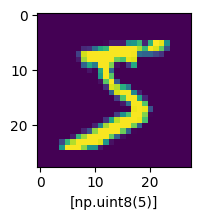

In [42]:
# This function is used to display first image from the dataset

def plot_sample(X, Y, index):
    plt.figure(figsize=(15,2))
    plt.imshow(X[index])
    plt.xlabel([Y[0]])

plot_sample(X_train, Y_train, 0)

In [43]:
#Scale pixel values
#Original pixel range => (0 to 255)
#I convert it to (0 to 1) for better training

X_train = X_train / 255
X_test = X_test / 255

In [44]:
#Reshape images for CNN
#CNN needs 3D shape => (height, width, channels)
#black & white => 1 channel

X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

In [45]:
#Build CNN Model
model = keras.models.Sequential([

    # First Convolution Block => [32 filters]
    keras.layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)),
    keras.layers.MaxPooling2D((2,2)),

    # Second Convolution Block => [64 filters]
    keras.layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),

    # Flatten before Dense layers
    keras.layers.Flatten(),

    # Fully Connected Layer
    keras.layers.Dense(64, activation='relu'),

    # Output Layer (10 digits=> 0-9)
    keras.layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [46]:
#Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [47]:
#Train the model
# epochs=5 (means model will see dataset 5 times)

model.fit(X_train, Y_train, epochs=5)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9093 - loss: 0.3066
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9828 - loss: 0.0513
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9885 - loss: 0.0345
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9929 - loss: 0.0225
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9947 - loss: 0.0159


In [48]:
#Test model on unseen data

loss, accuracy = model.evaluate(X_test, Y_test)

print("Test Accuracy:", accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9851 - loss: 0.0498
Test Accuracy: 0.9882000088691711


Enter the index of the image you want to predict: 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step


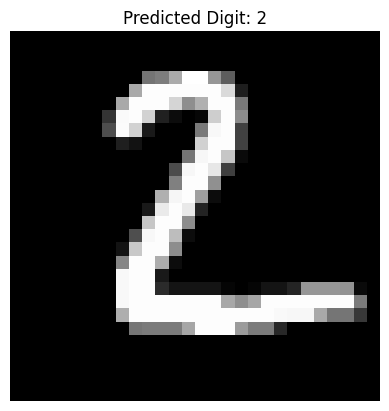

In [59]:
#Predict one image
index = int(input("Enter the index of the image you want to predict: "))

prediction = model.predict(X_test[index:index+1])
predicted_digit = np.argmax(prediction)

plt.imshow(X_test[index].reshape(28,28), cmap='gray')
plt.title("Predicted Digit: " + str(predicted_digit))
plt.axis('off')
plt.show()